# Ledoit–Wolf shrinkage, from scratch

**pyportfolios.com** · [/research/ledoit-wolf-shrinkage](https://pyportfolios.com/research/ledoit-wolf-shrinkage) · 11 SPDR sector ETFs, 2018–2024 · NumPy · Pandas · scikit-learn · yfinance

The sample covariance matrix is an error-maximiser in disguise: the mean–variance
optimiser pours weight into exactly the directions it has estimated worst. In this
notebook we

1. measure how badly conditioned the sample covariance of the 11 sector ETFs is
   on a short window (T=60, N=11),
2. build the Ledoit–Wolf estimator from scratch and cross-check it against
   `sklearn.covariance.LedoitWolf` to machine precision,
3. watch shrinkage lift the small eigenvalues (the ones inversion amplifies), and
4. run the honest test: a rolling out-of-sample minimum-variance backtest,
   sample vs shrunk.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.covariance import LedoitWolf

plt.rcParams["figure.figsize"] = (10, 5)

## 1 · Data: the 11 sector SPDRs

One ETF per GICS sector. XLC only exists since June 2018, so the balanced panel
runs from there — about 1,600 trading days of 11 daily return series.

In [2]:
SECTORS = ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]

px = yf.download(SECTORS, start="2018-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"][SECTORS].dropna()
rets = px.pct_change().dropna()
print(f"{rets.shape[0]} days x {rets.shape[1]} assets, {rets.index[0].date()} .. {rets.index[-1].date()}")

1644 days x 11 assets, 2018-06-20 .. 2024-12-31


## 2 · The estimator, from scratch

Shrink the sample matrix toward the spherical target F = μ·I (μ = average sample
variance) with the analytic intensity δ* = b²/d² — noise over distance-from-target.
No cross-validation, no tuning.

In [3]:
def ledoit_wolf(X):
    """X: (T, N) returns, rows = observations. Returns (shrunk_cov, delta)."""
    T, N = X.shape
    X = X - X.mean(axis=0)
    S = X.T @ X / T                       # sample covariance (MLE)
    mu = np.trace(S) / N                  # average variance
    F = mu * np.eye(N)                    # spherical target

    d2 = ((S - F) ** 2).sum() / N         # distance from target
    X2 = X ** 2
    b2 = ((X2.T @ X2) / T - S ** 2).sum() / (N * T)   # noise in S
    b2 = min(b2, d2)                      # never shrink past the target
    delta = b2 / d2 if d2 > 0 else 0.0

    return (1 - delta) * S + delta * F, delta

## 3 · Conditioning, and the sklearn cross-check

Estimate on the last 60 trading days only — 11 assets from 60 observations, the
regime where the sample matrix is at its most treacherous. Then verify our twelve
lines against scikit-learn.

delta (ours)    : 0.2761
delta (sklearn) : 0.2761
max |diff| vs sklearn covariance: 1.36e-20

condition number: sample 58  ->  shrunk 12


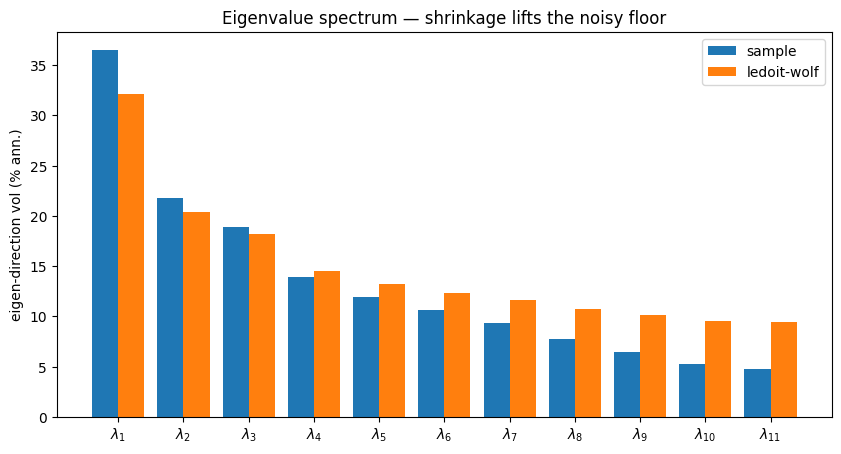

In [4]:
X = rets.iloc[-60:].to_numpy()

Xc = X - X.mean(axis=0)
S  = Xc.T @ Xc / len(X)
LW_cov, delta = ledoit_wolf(X)

skl = LedoitWolf().fit(X)
print(f"delta (ours)    : {delta:.4f}")
print(f"delta (sklearn) : {skl.shrinkage_:.4f}")
print(f"max |diff| vs sklearn covariance: {np.abs(skl.covariance_ - LW_cov).max():.2e}")

eig_s  = np.sort(np.linalg.eigvalsh(S))[::-1]
eig_lw = np.sort(np.linalg.eigvalsh(LW_cov))[::-1]
print(f"\ncondition number: sample {eig_s[0]/eig_s[-1]:,.0f}  ->  shrunk {eig_lw[0]/eig_lw[-1]:,.0f}")

x = np.arange(1, 12)
plt.bar(x - 0.2, np.sqrt(eig_s  * 252) * 100, 0.4, label="sample")
plt.bar(x + 0.2, np.sqrt(eig_lw * 252) * 100, 0.4, label="ledoit-wolf")
plt.xticks(x, [f"$\\lambda_{{{i}}}$" for i in x])
plt.ylabel("eigen-direction vol (% ann.)")
plt.title("Eigenvalue spectrum — shrinkage lifts the noisy floor"); plt.legend();

Inversion divides by the *smallest* eigenvalues. Shrinkage barely touches the top of
the spectrum (the market factor) but lifts the floor — exactly the directions the
optimiser would otherwise bet on hardest.

## 4 · The out-of-sample test

Minimum-variance weights w ∝ Σ⁻¹·1, re-estimated every 21 trading days on the
trailing 60-day window, held forward. Same data, same rebalance dates — the only
difference is the covariance estimator.

In [5]:
def min_var(cov):
    w = np.linalg.solve(cov, np.ones(cov.shape[0]))
    return w / w.sum()

WINDOW, HOLD = 60, 21
oos = {"sample": [], "ledoit-wolf": []}
idx, max_w, turn, prev = [], {k: 0.0 for k in oos}, {k: [] for k in oos}, {k: None for k in oos}

for i in range(WINDOW, len(rets) - 1, HOLD):
    Xw = rets.iloc[i - WINDOW:i].to_numpy()
    Xc = Xw - Xw.mean(axis=0)
    covs = {"sample": Xc.T @ Xc / WINDOW, "ledoit-wolf": ledoit_wolf(Xw)[0]}
    seg = rets.iloc[i:i + HOLD].to_numpy()
    idx.extend(rets.index[i:i + HOLD])
    for name, cov in covs.items():
        w = min_var(cov)
        max_w[name] = max(max_w[name], np.abs(w).max())
        if prev[name] is not None:
            turn[name].append(np.abs(w - prev[name]).sum())
        prev[name] = w
        oos[name].extend(seg @ w)

for name in oos:
    s = pd.Series(oos[name], index=idx)
    print(f"{name:>12}: OOS vol {s.std(ddof=1) * np.sqrt(252):6.2%}   "
          f"max |w| {max_w[name]:5.1%}   avg turnover {np.mean(turn[name]):.2f}/rebalance")

      sample: OOS vol 16.07%   max |w| 169.7%   avg turnover 1.60/rebalance
 ledoit-wolf: OOS vol 15.50%   max |w| 76.6%   avg turnover 0.86/rebalance


## 5 · Rolling realised risk

The same result through time: rolling 63-day annualised volatility of the two
out-of-sample return streams.

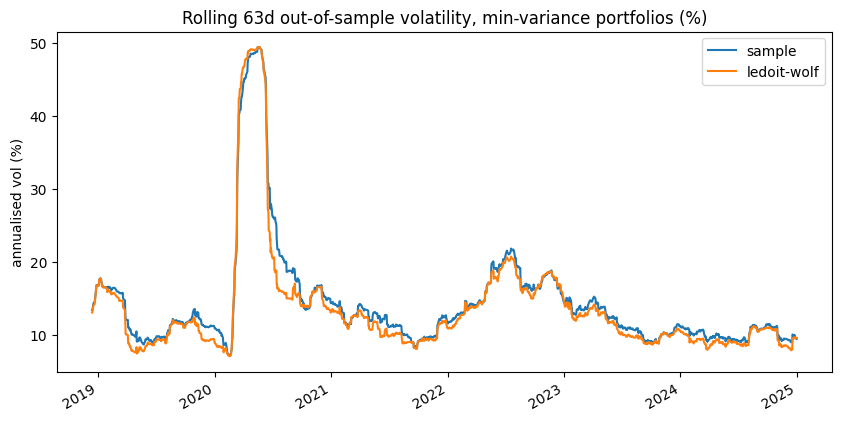

In [6]:
roll = pd.DataFrame({k: pd.Series(v, index=idx) for k, v in oos.items()})
(roll.rolling(63).std(ddof=1) * np.sqrt(252) * 100).dropna().plot(
    title="Rolling 63d out-of-sample volatility, min-variance portfolios (%)")
plt.ylabel("annualised vol (%)");

## Takeaways

- With N=11 and T=60 the sample covariance is genuinely ill-conditioned; inversion
  amplifies its noisiest directions and the optimiser bets on them.
- The whole fix is twelve lines, and δ is analytic — the data tells you how much
  to trust it. Our from-scratch estimator matches sklearn to machine precision.
- Out of sample, shrinkage delivers lower realised vol, saner max weights and less
  turnover — a free lunch paid for by accepting a little bias.
- Reach for Ledoit–Wolf by default whenever N is comparable to T.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*